In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [38]:
def show(img, title="",cmap=None):
    plt.figure(figsize=(8,6))

    if cmap:
        plt.imshow(img,cmap=cmap)
    else:
        if len(img.shape) == 3:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

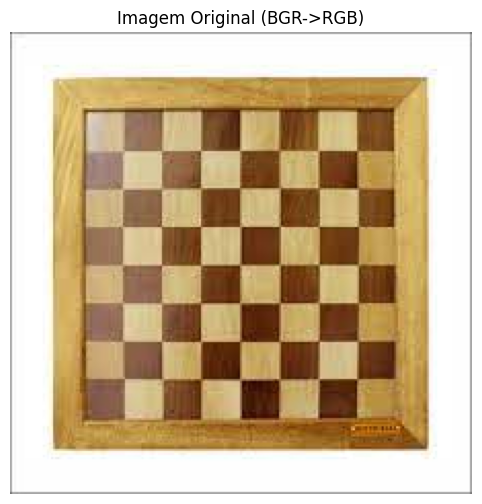

In [104]:
#Troque para o caminho da sua imagem
#IMG_PATH = "arroz.png"
IMG_PATH = "xadrez.jpg"

img = cv2.imread(IMG_PATH)

if img is None:
    raise FileNotFoundError("Não consegui abrir: {IMG_PATH}")
show(img, "Imagem Original (BGR->RGB)")

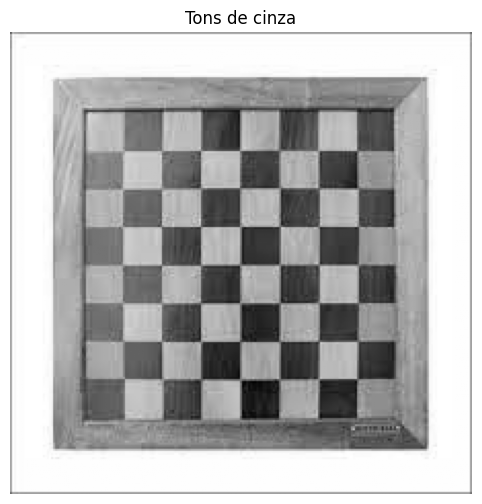

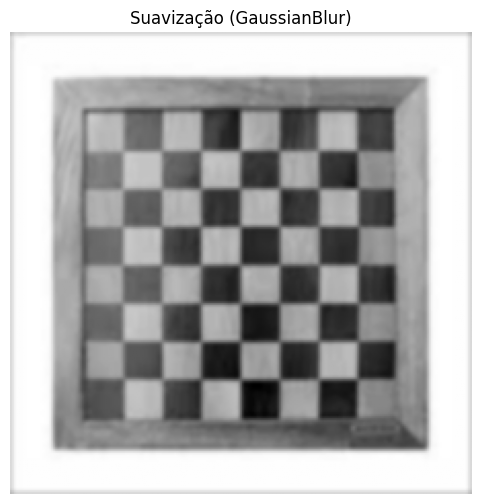

In [105]:
#Pré processamento
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

show(gray, "Tons de cinza", cmap = "gray")
show(blur, "Suavização (GaussianBlur)", cmap = "gray")

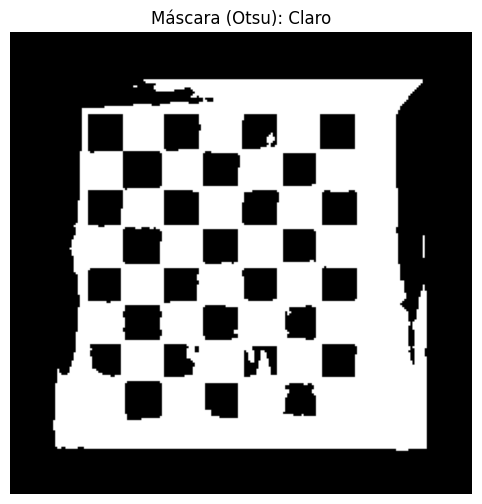

In [106]:
#Aplicação do Otsu
#Otsu encontra um limiar automaticamente (separa claro/escuro
_,bw_otsu = cv2.threshold(blur,0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#Garantir que um seja branco 255 e o outro preto. Gerelmante Otsu já faz isso.
if np.mean(bw_otsu) > 127:
    bw_otsu = cv2.bitwise_not(bw_otsu)

show(bw_otsu, "Máscara (Otsu): Claro", cmap = "gray")
#

In [107]:
#Escolha do limiar
thresh_value, bw_otsu = cv2.threshold(blur,0,255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Limiar escolhido pelo Otsu: ", thresh_value)

Limiar escolhido pelo Otsu:  168.0


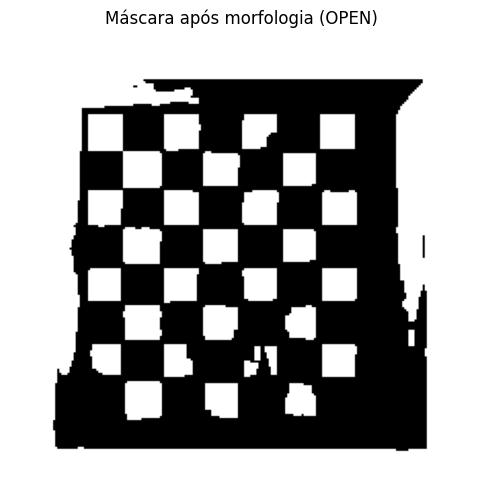

In [108]:
#Remoção do ruído
kernel = np.ones((3,3), np.uint8)
bw_clean = cv2.morphologyEx(bw_otsu, cv2.MORPH_OPEN, kernel, iterations=1)
show(bw_clean, "Máscara após morfologia (OPEN)", cmap= "gray")

In [118]:
#Contagem
#Parametros simples de filtragem de área
MIN_AREA = 10 #Ignora pontos pequenos
MAX_AREA = 5000 #Ignora manchas grandes.

In [119]:
#contar
def contar(mask, min_area=MIN_AREA, max_area = MAX_AREA):
    #retorna total, bouding boxex, centroids
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    count = 0
    boxes = []
    cents = []

    for label in range(1,n): #0 = frente
        area = int(stats[label, cv2.CC_STAT_AREA])

        if min_area <= area <= max_area:
            count += 1
            x = int(stats[label, cv2.CC_STAT_LEFT])
            y = int(stats[label, cv2.CC_STAT_TOP])
            w = int(stats[label, cv2.CC_STAT_WIDTH])
            h = int(stats[label, cv2.CC_STAT_HEIGHT])
            boxes.append((x,y,w,h))
            cents.append(tuple(map(int,centroids[label])))
    return count, boxes, cents, labels

In [120]:
count_otsu, boxes_otsu, cents_otsu, labels = contar(bw_clean, MIN_AREA, MAX_AREA)

In [121]:
count_otsu

30

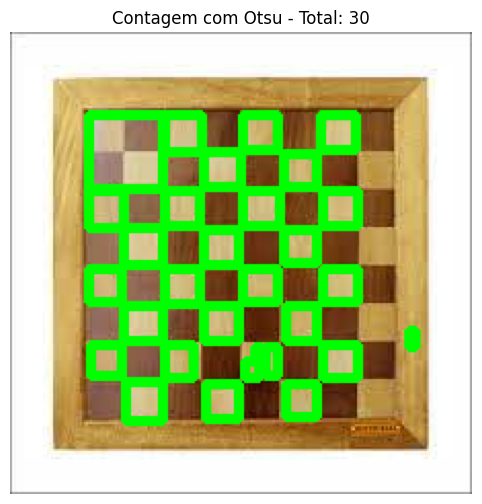

In [122]:
vis_otsu = img.copy()
for i, (x,y,w,h) in enumerate(boxes_otsu, start = 1):
    cv2.rectangle(vis_otsu, (x,y), (x+w, y+h), (0,255,0),4)

show(vis_otsu, f"Contagem com Otsu - Total: {count_otsu}")